# IE6600 Quiz 9: Interactive Data Visualization (Cont.)
## Online Food Order Dataset — Altair

In [1]:
import sys
!{sys.executable} -m pip install altair vega_datasets wordcloud -q

import pandas as pd
import numpy as np
import altair as alt
alt.data_transformers.disable_max_rows()
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('onlinefoods.csv')

# Clean trailing whitespace in Feedback column
df['Feedback'] = df['Feedback'].str.strip()

# Drop any unnamed trailing columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (388, 12)
Columns: ['Age', 'Gender', 'Marital Status', 'Occupation', 'Monthly Income', 'Educational Qualifications', 'Family size', 'latitude', 'longitude', 'Pin code', 'Output', 'Feedback']


,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,Output,Feedback
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,Yes,Positive
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,Yes,Positive
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,Yes,Negative
3,22,Female,Single,Student,No Income,Graduate,6,12.9473,77.5616,560019,Yes,Positive
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,12.9850,77.5533,560010,Yes,Positive


---
# A. Customer Demographics & Trends

## 1. Histogram: Customer Age Distribution
Create a histogram showing the distribution of customer age.

In [2]:
alt.Chart(df).mark_bar().encode(
    alt.X('Age:Q', bin=alt.Bin(maxbins=15), title='Age'),
    alt.Y('count()', title='Number of Customers'),
    tooltip=['Age:Q', 'count()']
).properties(
    title='Customer Age Distribution',
    width=600, height=350
).interactive()

alt.Chart(...)

## 2. Bar Chart: Gender-Based Food Ordering Trends
Create a bar chart comparing the number of male and female customers.

In [3]:
alt.Chart(df).mark_bar().encode(
    alt.X('Gender:N', title='Gender'),
    alt.Y('count()', title='Number of Customers'),
    alt.Color('Gender:N'),
    tooltip=['Gender:N', 'count()']
).properties(
    title='Gender-Based Food Ordering Trends',
    width=400, height=350
).interactive()

alt.Chart(...)

## 3. Box Plot: Family Size Distribution
Create a box plot showing the distribution of family size.

In [4]:
alt.Chart(df).mark_boxplot(extent='min-max').encode(
    alt.Y('Family size:Q', title='Family Size'),
    tooltip=['Family size:Q']
).properties(
    title='Family Size Distribution',
    width=300, height=350
).interactive()

alt.Chart(...)

## 4. Pie Chart: Educational Qualifications of Customers
Visualize the proportion of customers in each education level category.

In [5]:
edu_counts = df['Educational Qualifications'].value_counts().reset_index()
edu_counts.columns = ['Education', 'Count']

alt.Chart(edu_counts).mark_arc(innerRadius=50).encode(
    alt.Theta('Count:Q'),
    alt.Color('Education:N', title='Education Level'),
    tooltip=['Education:N', 'Count:Q']
).properties(
    title='Educational Qualifications of Customers',
    width=400, height=400
)

alt.Chart(...)

## 5. Scatter Plot: Relationship Between Age and Family Size
Plot Age vs. Family Size and color the points based on gender.

In [6]:
alt.Chart(df).mark_circle(size=60, opacity=0.6).encode(
    alt.X('Age:Q', title='Age'),
    alt.Y('Family size:Q', title='Family Size'),
    alt.Color('Gender:N'),
    tooltip=['Age:Q', 'Family size:Q', 'Gender:N', 'Occupation:N']
).properties(
    title='Age vs Family Size (colored by Gender)',
    width=600, height=400
).interactive()

alt.Chart(...)

## 6. Heatmap: Family Size vs. Age
Create a heatmap showing how family size and age are correlated.

In [7]:
alt.Chart(df).mark_rect().encode(
    alt.X('Age:O', title='Age'),
    alt.Y('Family size:O', title='Family Size'),
    alt.Color('count():Q', scale=alt.Scale(scheme='blues'), title='Count'),
    tooltip=['Age:O', 'Family size:O', 'count():Q']
).properties(
    title='Heatmap: Family Size vs Age',
    width=600, height=300
).interactive()

alt.Chart(...)

## 7. Bar Chart: Most Common Customer Occupations
Identify the most common occupations among customers who order food online.

In [8]:
alt.Chart(df).mark_bar().encode(
    alt.X('count()', title='Number of Customers'),
    alt.Y('Occupation:N', sort='-x', title='Occupation'),
    alt.Color('Occupation:N', legend=None),
    tooltip=['Occupation:N', 'count()']
).properties(
    title='Most Common Customer Occupations',
    width=500, height=300
).interactive()

alt.Chart(...)

## 8. Scatter Plot: Geographic Distribution (Age vs. Latitude)
Create a scatter plot showing the relationship between customer age and latitude.

In [9]:
alt.Chart(df).mark_circle(size=50, opacity=0.5).encode(
    alt.X('Age:Q', title='Age'),
    alt.Y('latitude:Q', title='Latitude'),
    alt.Color('Output:N', scale=alt.Scale(domain=['Yes', 'No'], range=['#2ecc71', '#e74c3c'])),
    tooltip=['Age:Q', 'latitude:Q', 'Gender:N', 'Output:N']
).properties(
    title='Age vs Latitude',
    width=600, height=400
).interactive()

alt.Chart(...)

## 9. Violin Plot: Comparing Family Size Distribution by Gender
Compare the family size distributions for male vs. female customers.

In [10]:
alt.Chart(df).transform_density(
    'Family size',
    as_=['Family size', 'density'],
    groupby=['Gender']
).mark_area(orient='horizontal', opacity=0.5).encode(
    alt.X('density:Q', title='Density', stack='center', impute=None,
          axis=alt.Axis(labels=False, values=[0], grid=False, ticks=True)),
    alt.Y('Family size:Q', title='Family Size'),
    alt.Color('Gender:N'),
    alt.Row('Gender:N', title=''),
    tooltip=['Gender:N']
).properties(
    title='Family Size Distribution by Gender',
    width=400, height=200
)

alt.Chart(...)

## 10. Geographic Analysis: Customer Locations on a Map
Create an interactive scatter map using latitude and longitude to visualize customer locations.

In [11]:
alt.Chart(df).mark_circle(size=80, opacity=0.6).encode(
    alt.X('longitude:Q', title='Longitude', scale=alt.Scale(zero=False)),
    alt.Y('latitude:Q', title='Latitude', scale=alt.Scale(zero=False)),
    alt.Color('Output:N', scale=alt.Scale(domain=['Yes', 'No'], range=['#2ecc71', '#e74c3c']),
              title='Satisfied'),
    alt.Size('Family size:Q', title='Family Size'),
    tooltip=['Age:Q', 'Gender:N', 'Occupation:N', 'Output:N', 'Pin code:Q', 'latitude:Q', 'longitude:Q']
).properties(
    title='Geographic Distribution of Customers (Bangalore)',
    width=600, height=500
).interactive()

alt.Chart(...)

---
# B. Customer Satisfaction & Feedback Analysis

## 11. Bar Chart: Customer Satisfaction Levels by Gender
Compare the proportion of satisfied vs. unsatisfied customers across genders.

In [12]:
alt.Chart(df).mark_bar().encode(
    alt.X('Gender:N', title='Gender'),
    alt.Y('count()', title='Count'),
    alt.Color('Output:N', scale=alt.Scale(domain=['Yes', 'No'], range=['#2ecc71', '#e74c3c']),
              title='Satisfied'),
    alt.XOffset('Output:N'),
    tooltip=['Gender:N', 'Output:N', 'count()']
).properties(
    title='Customer Satisfaction by Gender',
    width=400, height=350
).interactive()

alt.Chart(...)

## 12. Box Plot: Impact of Age on Customer Satisfaction
Create a box plot comparing age distributions for satisfied vs. unsatisfied customers.

In [13]:
alt.Chart(df).mark_boxplot(extent='min-max').encode(
    alt.X('Output:N', title='Satisfied (Output)'),
    alt.Y('Age:Q', title='Age'),
    alt.Color('Output:N', scale=alt.Scale(domain=['Yes', 'No'], range=['#2ecc71', '#e74c3c']),
              title='Satisfied'),
    tooltip=['Output:N']
).properties(
    title='Age Distribution by Satisfaction Level',
    width=350, height=400
).interactive()

alt.Chart(...)

## 13. Scatter Plot with Tooltip: Monthly Income vs. Age
Create a scatter plot of Monthly Income vs. Age with a tooltip displaying Educational Qualifications and Occupation.

In [14]:
income_order = ['No Income', 'Below Rs.10000', '10001 to 25000', '25001 to 50000', 'More than 50000']

alt.Chart(df).mark_circle(size=70, opacity=0.6).encode(
    alt.X('Age:Q', title='Age'),
    alt.Y('Monthly Income:N', sort=income_order, title='Monthly Income'),
    alt.Color('Output:N', scale=alt.Scale(domain=['Yes', 'No'], range=['#2ecc71', '#e74c3c'])),
    tooltip=['Age:Q', 'Monthly Income:N', 'Educational Qualifications:N', 'Occupation:N', 'Output:N']
).properties(
    title='Monthly Income vs Age',
    width=600, height=350
).interactive()

alt.Chart(...)

## 14. Pie Chart: Positive vs. Negative Customer Feedback
What percentage of customers provided positive vs. negative feedback?

In [15]:
feedback_counts = df['Feedback'].value_counts().reset_index()
feedback_counts.columns = ['Feedback', 'Count']

alt.Chart(feedback_counts).mark_arc(innerRadius=50).encode(
    alt.Theta('Count:Q'),
    alt.Color('Feedback:N', scale=alt.Scale(domain=['Positive', 'Negative'],
              range=['#2ecc71', '#e74c3c']), title='Feedback'),
    tooltip=['Feedback:N', 'Count:Q']
).properties(
    title='Positive vs Negative Customer Feedback',
    width=400, height=400
)

alt.Chart(...)

## 15. Word Cloud: Most Common Words in Customer Feedback
Generate a word cloud from the Feedback column to highlight common themes.

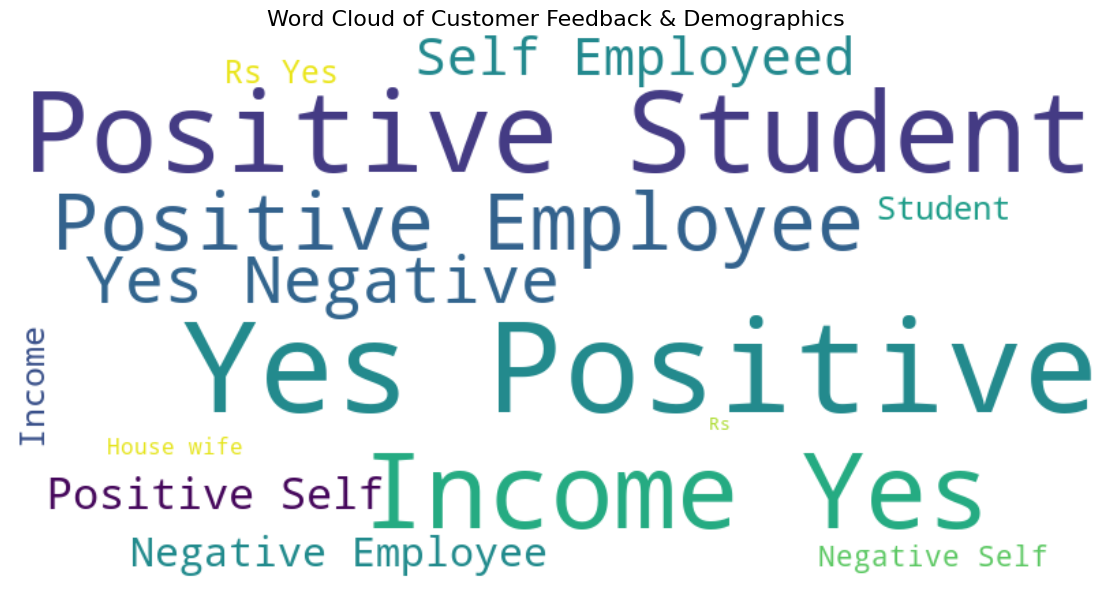

In [16]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Since Feedback only has 'Positive'/'Negative', we create a descriptive word cloud
# by combining Feedback with other categorical columns for richer text
text_data = []
for _, row in df.iterrows():
    text_data.append(f"{row['Feedback']} {row['Occupation']} {row['Monthly Income']} {row['Output']}")

text = ' '.join(text_data)

wordcloud = WordCloud(width=800, height=400, background_color='white',
                      colormap='viridis', max_words=50).generate(text)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Word Cloud of Customer Feedback & Demographics', fontsize=16)
plt.tight_layout()
plt.show()

## 16. Grouped Bar Chart: Satisfaction by Occupation
Compare Occupation vs. Satisfaction Levels (Yes/No).

In [17]:
alt.Chart(df).mark_bar().encode(
    alt.X('Occupation:N', title='Occupation'),
    alt.Y('count()', title='Count'),
    alt.Color('Output:N', scale=alt.Scale(domain=['Yes', 'No'], range=['#2ecc71', '#e74c3c']),
              title='Satisfied'),
    alt.XOffset('Output:N'),
    tooltip=['Occupation:N', 'Output:N', 'count()']
).properties(
    title='Satisfaction by Occupation',
    width=500, height=350
).interactive()

alt.Chart(...)

## 17. Heatmap: Correlation Between Age, Family Size, and Satisfaction
Show the correlation between Age, Family Size, and Satisfaction Levels using a heatmap.

In [18]:
# Encode Output as numeric for correlation
df_corr = df[['Age', 'Family size']].copy()
df_corr['Satisfied'] = (df['Output'] == 'Yes').astype(int)

corr = df_corr.corr().reset_index().melt('index')
corr.columns = ['Variable 1', 'Variable 2', 'Correlation']

alt.Chart(corr).mark_rect().encode(
    alt.X('Variable 1:N', title=''),
    alt.Y('Variable 2:N', title=''),
    alt.Color('Correlation:Q', scale=alt.Scale(scheme='redblue', domain=[-1, 1]),
              title='Correlation'),
    tooltip=['Variable 1:N', 'Variable 2:N', alt.Tooltip('Correlation:Q', format='.3f')]
).properties(
    title='Correlation: Age, Family Size & Satisfaction',
    width=350, height=350
).configure_axis(labelFontSize=12)

alt.Chart(...)

## 18. Linked Plots: Age vs. Family Size and Age vs. Satisfaction
Create two linked scatter plots with interactive selection.

In [19]:
brush = alt.selection_interval()

chart1 = alt.Chart(df).mark_circle(size=60, opacity=0.6).encode(
    alt.X('Age:Q', title='Age'),
    alt.Y('Family size:Q', title='Family Size'),
    color=alt.when(brush).then('Gender:N').otherwise(alt.value('lightgray')),
    tooltip=['Age:Q', 'Family size:Q', 'Gender:N']
).properties(
    title='Age vs Family Size',
    width=350, height=300
).add_params(brush)

chart2 = alt.Chart(df).mark_circle(size=60, opacity=0.6).encode(
    alt.X('Age:Q', title='Age'),
    alt.Y('Output:N', title='Satisfaction (Output)'),
    color=alt.when(brush).then('Gender:N').otherwise(alt.value('lightgray')),
    tooltip=['Age:Q', 'Output:N', 'Occupation:N']
).properties(
    title='Age vs Satisfaction',
    width=350, height=300
).add_params(brush)

chart1 | chart2

alt.HConcatChart(...)

## 19. Interactive Mean Calculation: Family Size by Occupation
Create a bar chart where customers can filter by Occupation to calculate the mean family size dynamically.

In [20]:
selection = alt.selection_point(fields=['Occupation'], bind='legend')

alt.Chart(df).mark_bar().encode(
    alt.X('Occupation:N', title='Occupation'),
    alt.Y('mean(Family size):Q', title='Mean Family Size'),
    alt.Color('Occupation:N', title='Occupation'),
    opacity=alt.condition(selection, alt.value(1), alt.value(0.2)),
    tooltip=['Occupation:N', alt.Tooltip('mean(Family size):Q', format='.2f')]
).properties(
    title='Mean Family Size by Occupation (Click Legend to Filter)',
    width=500, height=350
).add_params(selection).interactive()

alt.Chart(...)

## 20. Dynamic Bar & Heatmap: Occupation vs. Age & Family Size
Create a bar chart for Occupation and link it to a heatmap showing respondents based on Age and Family Size.

In [21]:
selection = alt.selection_point(fields=['Occupation'])

bar_chart = alt.Chart(df).mark_bar().encode(
    alt.X('Occupation:N', title='Occupation'),
    alt.Y('count()', title='Count'),
    color=alt.when(selection).then('Occupation:N').otherwise(alt.value('lightgray')),
    tooltip=['Occupation:N', 'count()']
).properties(
    title='Click an Occupation to Filter Heatmap',
    width=400, height=250
).add_params(selection)

heatmap = alt.Chart(df).mark_rect().encode(
    alt.X('Age:O', title='Age'),
    alt.Y('Family size:O', title='Family Size'),
    alt.Color('count():Q', scale=alt.Scale(scheme='oranges'), title='Count'),
    tooltip=['Age:O', 'Family size:O', 'count():Q']
).properties(
    title='Respondents by Age & Family Size',
    width=500, height=250
).transform_filter(selection)

bar_chart & heatmap

alt.VConcatChart(...)